In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder  
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [41]:
df=pd.read_csv("matches_cleaned.csv")

In [42]:
df

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bengaluru,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,normal,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,normal,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,normal,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,normal,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,normal,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,normal,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,normal,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,MA Chidambaram Stadium,Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,normal,Nitin Menon,VK Sharma


In [43]:
df=df[['team1','team2','toss_winner','venue','winner']]

In [44]:
df

,team1,team2,toss_winner,venue,winner
0,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,Kolkata Knight Riders
1,Punjab Kings,Chennai Super Kings,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings
2,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,Feroz Shah Kotla,Delhi Capitals
3,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,Wankhede Stadium,Royal Challengers Bengaluru
4,Kolkata Knight Riders,Sunrisers Hyderabad,Deccan Chargers,Eden Gardens,Kolkata Knight Riders
...,...,...,...,...,...
1090,Punjab Kings,Sunrisers Hyderabad,Punjab Kings,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Sunrisers Hyderabad
1091,Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,"Narendra Modi Stadium, Ahmedabad",Kolkata Knight Riders
1092,Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals
1093,Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,MA Chidambaram Stadium,Sunrisers Hyderabad


In [45]:
label_encoder = LabelEncoder()
df['team1'] = label_encoder.fit_transform(df['team1'])
df['team2'] = label_encoder.fit_transform(df['team2'])
df['toss_winner'] = label_encoder.fit_transform(df['toss_winner'])
df['venue'] = label_encoder.fit_transform(df['venue'])
df['winner'] = label_encoder.fit_transform(df['winner'])


C:\Users\Rajat\AppData\Local\Temp\ipykernel_16896\1274724222.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['team1'] = label_encoder.fit_transform(df['team1'])
C:\Users\Rajat\AppData\Local\Temp\ipykernel_16896\1274724222.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['team2'] = label_encoder.fit_transform(df['team2'])
C:\Users\Rajat\AppData\Local\Temp\ipykernel_16896\1274724222.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

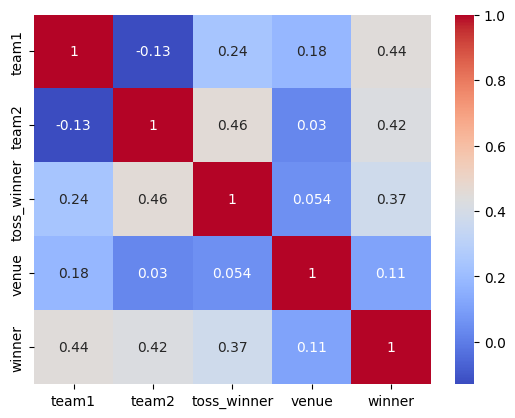

In [46]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [47]:
x=df.drop('winner', axis=1)
y=df['winner']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)


In [48]:
rfc=RandomForestClassifier(n_estimators=300, random_state=42, max_depth=10)
rfc.fit(x_train, y_train)
y_pred = rfc.predict(x_test)


In [49]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))  


Confusion Matrix:
 [[20  1  0  0  0  0  0  2  0  2  0  0  2  0  0]
 [ 2  7  0  0  0  2  0  0  0  3  1  0  1  4  0]
 [ 0  0  2  0  0  1  0  1  0  1  0  0  1  0  0]
 [ 0  0  0  3  0  0  0  0  0  0  1  0  1  1  0]
 [ 1  0  0  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 3  0  0  0  0 18  0  0  0  0  3  0  1  3  0]
 [ 0  1  0  0  0  1  1  0  0  1  0  0  2  0  0]
 [ 3  1  0  1  0  4  0  6  0  2  1  0  0  2  0]
 [ 0  0  0  0  0  1  0  0  0  0  1  0  0  0  0]
 [ 1  3  0  0  0  1  0  1  0  7  4  0  7  2  0]
 [ 5  0  0  0  0  1  0  4  0  2 10  0  2  1  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  1  0  1  0]
 [ 0  3  0  0  0  3  0  5  0  0  1  0 19  2  0]
 [ 1  2  0  0  0  0  0  3  0  1  0  0  1  6  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0  0  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.74      0.63        27
           1       0.39      0.35      0.37        20
           2       1.00      0.33      0.50         6
           3      

c:\Users\Rajat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rajat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rajat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [50]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(x_train, y_train)
y_pred = dtc.predict(x_test)

In [51]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[20  1  0  0  0  0  0  2  0  2  0  0  2  0  0]
 [ 2  5  1  0  0  2  0  1  0  3  1  0  1  4  0]
 [ 0  1  2  0  0  1  0  1  0  0  0  0  1  0  0]
 [ 0  0  1  5  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  2  0  0  0  0  0  0  0  0  0]
 [ 3  0  0  0  0 14  1  1  0  2  0  2  1  4  0]
 [ 0  0  0  1  0  1  3  1  0  0  0  0  0  0  0]
 [ 2  0  0  0  0  3  0  9  0  2  1  1  0  2  0]
 [ 0  0  0  1  0  0  0  0  0  0  1  0  0  0  0]
 [ 1  3  0  0  0  1  0  1  0 10  4  0  5  1  0]
 [ 3  0  0  0  0  1  0  5  0  4  9  0  2  1  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  1  0  1  0]
 [ 1  4  0  0  0  6  0  4  0  1  1  1 13  2  0]
 [ 1  2  0  0  0  0  0  3  0  3  0  0  1  4  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0  0  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.74      0.67        27
           1       0.31      0.25      0.28        20
           2       0.50      0.33      0.40         6
           3      

c:\Users\Rajat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rajat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rajat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave